In [1]:
import sys
import itertools
sys.path.append('../src')

from typing import Sequence

import numpy as np
from numpy.typing import NDArray

import jax
from jax import random
import jax.numpy as jnp

import pandas as pd

import numpyro
from numpyro import distributions as dist
from numpyro.contrib.hsgp.laplacian import eigenfunctions
from numpyro.contrib.hsgp.spectral_densities import diag_spectral_density_matern
from numpyro.infer import MCMC, Predictive
from numpyro.infer.initialization import init_to_median

# Custom modules
from numpyro_utils import fit_mcmc, posterior_predictive_mcmc
import visuals
import model_utils

import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid', palette='deep')

## Import contact data

In [2]:
# POLYMOD
df_cnt = pd.read_csv('../data/polymod/fine_age.csv')

# German population
df_pop = pd.read_csv('../data/germany-population-2011.csv')

Pre-process the population data

In [3]:
df_pop.rename({'gender': 'sex', 'pop': 'p'}, inplace=True, axis=1)
df_pop['sex'] = df_pop['sex'].map(lambda x: 'M' if x == 'Male' else 'F')

In [4]:
def expand_grid(data_dict):
  rows = itertools.product(*data_dict.values())
  return pd.DataFrame.from_records(rows, columns=data_dict.keys())

df_grid = expand_grid({
  'age_part': np.arange(0, 85, 1),
  'sex_part': ['M', 'F'],
  'age_cnt': np.arange(0, 85, 1),
  'sex_cnt': ['M', 'F'],
})

In [5]:
df_merged = pd.merge(df_grid,
                     df_cnt,
                     how='left',
                     on=['age_part', 'sex_part', 'age_cnt', 'sex_cnt'])
df_merged = pd.merge(df_merged,
                     df_pop,
                     how='left',
                     left_on=['age_cnt', 'sex_cnt'],
                     right_on=['age', 'sex'])

df_merged['sex_part'] = pd.Categorical(df_merged['sex_part'], categories=['M', 'F'])
df_merged['sex_cnt'] = pd.Categorical(df_merged['sex_cnt'], categories=['M', 'F'])
df_merged.reset_index(names='id', inplace=True)
df_merged = df_merged.sort_values(by=['sex_part', 'sex_cnt', 'age_part', 'age_cnt'])

In [6]:
y = df_merged['y'][~df_merged['y'].isna()].values
yid = df_merged['id'][~df_merged['y'].isna()].values

df_merged['n'] = np.where(df_merged['n'].isna(), 1.0, df_merged['n'])
df_merged['s'] = np.where(df_merged['s'].isna(), 1.0, df_merged['s'])
offsets = jnp.array((np.log(df_merged['n']) + np.log(df_merged['s']) + np.log(df_merged['p'])))

In [7]:
@jax.tree_util.register_pytree_node_class
class BRCModel:
    def __init__(self,
                 df_cnt: pd.DataFrame,
                 df_pop: pd.DataFrame,
                 M: int | list[int],
                 L: float | list[float]):
        self.cnt = df_cnt
        self.pop = df_pop

        # HSGP hyper-parameters
        self.M = M
        self.L = L

        # Constants
        self.G = 4  # No. of gender groups
        self.A = 85  # No. of age groups

        self._preprocess_input()
        self._precompute_grid()
        self._precompute_indices()

    def _expand_grid(self):
        data_dict = {
            'age_part': np.arange(0, 85, 1),
            'sex_part': ['M', 'F'],
            'age_cnt': np.arange(0, 85, 1),
            'sex_cnt': ['M', 'F'],
        }
        rows = itertools.product(*data_dict.values())
        return pd.DataFrame.from_records(rows, columns=data_dict.keys())
    
    def _preprocess_input(self):
        self.grid = self._expand_grid()
        x = pd.merge(self.grid,
                     self.cnt,
                     how='left',
                     on=['age_part', 'sex_part', 'age_cnt', 'sex_cnt'])
        x = pd.merge(x,
                     self.pop,
                     how='left',
                     left_on=['age_cnt', 'sex_cnt'],
                     right_on=['age', 'sex'])

        x['sex_part'] = pd.Categorical(x['sex_part'], categories=['M', 'F'])
        x['sex_cnt'] = pd.Categorical(x['sex_cnt'], categories=['M', 'F'])
        x.reset_index(names='id', inplace=True)
        x = x.sort_values(by=['sex_part', 'sex_cnt', 'age_cnt', 'age_part'])
        
        # Extract non-missing values and their corresponding index
        self.y = x['y'][~x['y'].isna()].values
        self.yid = x['id'][~x['y'].isna()].values

        # Compute offsets
        x['n'] = np.where(x['n'].isna(), 1.0, x['n'])
        x['s'] = np.where(x['s'].isna(), 1.0, x['s'])
        self.log_n = jnp.log(x['n'].values)
        self.log_s = jnp.log(x['s'].values)
        self.log_p = jnp.log(x['p'].values)

    def _precompute_grid(self):
        X = model_utils.non_nuisance_grid(self.A)
        ltri_idx = model_utils.lower_tri_indices(self.A)
        Xstd = (X - X.mean(axis=0)) / X.std(axis=0)

        self.X_MM = Xstd[ltri_idx]
        self.X_FF = Xstd[ltri_idx]
        self.X_MF = X
    
    def _precompute_indices(self):
        self.sym_tri_idx = model_utils.symmetrize_from_lower_tri(self.A)
        self.tran_vec_idx = model_utils.transpose_vector_indices(self.A, self.A)

    def sample_latent_field(self, site, x, alpha, rho):
        phi = eigenfunctions(x=x, ell=self.L, m=self.M)
        spd = jnp.sqrt(
            diag_spectral_density_matern(
                nu=5/2, alpha=alpha, length=rho, ell=self.L, m=self.M, dim=2
            )
        )
        with numpyro.plate('basis', phi.shape[-1]):
            beta = numpyro.sample(site, dist.Normal(0, 1))

        return phi @ (spd * beta)

    def model(self):
        beta0 = numpyro.sample('baseline', dist.Normal(0., 10.).expand([self.G]))
        varphi = numpyro.sample('overdisp', dist.Exponential(1.))
        alpha = numpyro.sample('gp_scale', dist.HalfNormal(1.).expand([self.G-1]))
        rho = numpyro.sample('gp_lenscale', dist.InverseGamma(5., 5.).expand([self.G-1]))

        f_MM = self.sample_latent_field('beta_MM', self.X_MM, alpha[0], rho[0])[self.sym_tri_idx]
        f_FF = self.sample_latent_field('beta_FF', self.X_FF, alpha[1], rho[1])[self.sym_tri_idx]
        f_MF = self.sample_latent_field('beta_MF', self.X_MF, alpha[2], rho[2])
        f_FM = f_MF[self.tran_vec_idx]

        log_gam_MM = beta0[0] + f_MM
        log_gam_FF = beta0[1] + f_FF
        log_gam_MF = beta0[2] + f_MF
        log_gam_FM = beta0[3] + f_FM
        log_gam = numpyro.deterministic('log_cnt_rate', jnp.concat([log_gam_MM, log_gam_FF, log_gam_MF, log_gam_FM], axis=0))
        log_cint = numpyro.deterministic('log_cint', log_gam + self.log_p)
        log_mu = log_cint + self.log_n + self.log_s

        numpyro.sample('y', dist.NegativeBinomial2(mean=jnp.exp(log_mu[self.yid]), concentration=varphi), obs=self.y)

    def tree_flatten(self):
        children = ()
        aux_data = (
            self.L,
            self.m
        )
        return (children, aux_data)
  
    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children, **aux_data)

In [8]:
model_brc = BRCModel(df_cnt, df_pop, M=[30, 30], L=[1.5, 1.5])
mcmc = fit_mcmc(0, model_brc.model, num_warmup=500, num_samples=500, num_chains=2)

/Users/shozendan/Imperial/0_Research/high_res_brc/notebooks/../src/numpyro_utils.py:24: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(
sample: 100%|██████████| 1000/1000 [09:16<00:00,  1.80it/s, 31 steps of size 1.24e-01. acc. prob=0.86]  


Convert to arviz data for post processing.

In [10]:
idata = az.from_numpyro(mcmc)

Compute diagnostic summaries on key quantities

In [13]:
az.summary(idata, var_names='log_cint', kind='diagnostics')

,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_cint[0],0.017,0.012,1076.0,781.0,1.00
log_cint[1],0.014,0.010,1183.0,938.0,1.00
log_cint[2],0.012,0.008,1231.0,899.0,1.00
log_cint[3],0.011,0.008,1168.0,806.0,1.00
log_cint[4],0.012,0.008,1064.0,855.0,1.00
...,...,...,...,...,...
log_cint[28895],0.005,0.003,986.0,707.0,1.00
log_cint[28896],0.005,0.003,1111.0,819.0,1.00
log_cint[28897],0.004,0.003,1125.0,836.0,1.01
log_cint[28898],0.003,0.002,1608.0,984.0,1.00


In [19]:
func_dict = {
  "q05": lambda x: np.percentile(x, 5),
  "q50": lambda x: np.percentile(x, 50),
  "q95": lambda x: np.percentile(x, 95),
}
post_sum = az.summary(idata, var_names='log_cint', stat_funcs=func_dict, extend=False)

In [20]:
df_grid = model_brc.grid
df_grid['cint_q50'] = np.exp(post_sum['q50'].values)

In [21]:
df_mm = df_grid[(df_grid['sex_part'] == 'M') & (df_grid['sex_cnt'] == 'M')]

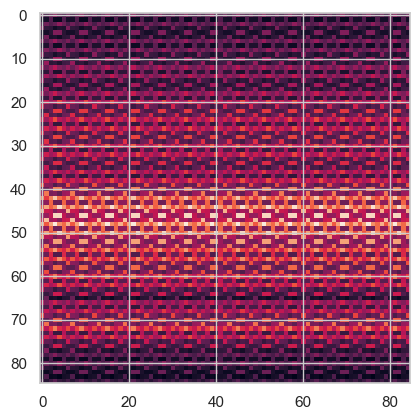

In [40]:
yhat = df_grid['cint_q50'].values[3*85*85:4*85*85].reshape((85, 85), order='C')
plt.imshow(yhat)

In [43]:
predictive = Predictive(model_brc.model, mcmc.get_samples())

In [45]:
y_pred = predictive(random.PRNGKey(0))

In [48]:
plt.hist(y_pred['y'], bins=20)

KeyboardInterrupt: 